# Using CPC2 and CMIIC2 (otagrum)

This notebook extends [plot_using_otagrum.ipynb](https://openturns.github.io/otagrum/master/auto_examples/plot_using_otagrum.html#sphx-glr-auto-examples-plot-using-otagrum-py) by also trying cpc2 and cmiic2.

In [115]:
import openturns as ot
import pyagrum as gum
from matplotlib import pylab as plt

import sys
sys.path.insert(0, "~/.local/lib/python3.14/site-packages")
import otagrum

In [116]:
def showDot(dotstring):
    try:
        # fails outside notebook
        import pyAgrum.lib.notebook as gnb

        gnb.showDot(dotstring)
    except ImportError:
        import pydot
        from io import BytesIO

        graph = pydot.graph_from_dot_data(dotstring)[0]
        with BytesIO() as f:
            f.write(graph.create_png())
            f.seek(0)
            img = plt.imread(f)
        fig = plt.imshow(img)
        fig.axes.axis("off")
        plt.show()

Creating the CBN structure
We begin by creating the CBN that will be used throughout this example.

To do so, we need a NamedDAG structure...



In [117]:
dag = gum.DAG()

In [118]:
mapping = {}
mapping["A"] = dag.addNode()  # Add node A
mapping["B"] = dag.addNode()  # Add node B
mapping["C"] = dag.addNode()  # Add node C
mapping["D"] = dag.addNode()  # Add node D

mapping["E"] = dag.addNode()  # Add node E
mapping["F"] = dag.addNode()  # Add node F
mapping["G"] = dag.addNode()  # Add node G
mapping["H"] = dag.addNode()  # Add node H
mapping["I"] = dag.addNode()  # Add node I

In [119]:
dag.addArc(mapping["A"], mapping["C"])  # Arc A -> C
dag.addArc(mapping["B"], mapping["C"])  # Arc B -> C
dag.addArc(mapping["C"], mapping["D"])  # Arc C -> D

dag.addArc(mapping["A"], mapping["E"])  # Arc A -> E
dag.addArc(mapping["F"], mapping["E"])  # Arc F -> E
dag.addArc(mapping["F"], mapping["G"])  # Arc F -> G
dag.addArc(mapping["G"], mapping["E"])  # Arc G -> E
dag.addArc(mapping["H"], mapping["D"])  # Arc H -> D
dag.addArc(mapping["H"], mapping["I"])  # Arc H -> I

print(dag)

{0,1,2,3,4,5,6,7,8} , {2->3,7->3,0->2,1->2,0->4,5->4,5->6,6->4,7->8}


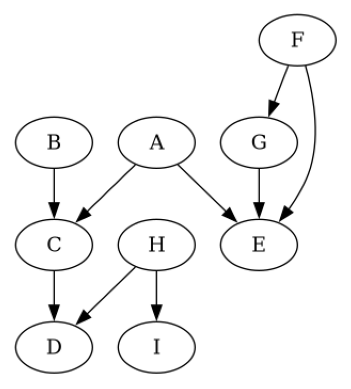

In [120]:
structure = otagrum.NamedDAG(dag, list(mapping.keys()))
showDot(structure.toDot())

Parameters of the CBN ... and a collection of marginals and local conditional copulas.



In [121]:
m_list = [ot.Uniform(0.0, 1.0) for i in range(structure.getSize())]  # Local marginals
lcc_list = []  # Local Conditional Copulas
for i in range(structure.getSize()):
    dim_lcc = structure.getParents(i).getSize() + 1
    R = ot.CorrelationMatrix(dim_lcc)
    for j in range(dim_lcc):
        for k in range(j):
            R[j, k] = 0.6
    lcc_list.append(ot.Normal([0.0] * dim_lcc, [1.0] * dim_lcc, R).getCopula())

Now that we have a NamedDAG structure and a collection of local conditional
copulas, we can construct a CBN.



In [122]:
cbn = otagrum.ContinuousBayesianNetwork(structure, m_list, lcc_list)

Having a CBN, we can now sample from it.



In [123]:
ot.RandomGenerator.SetSeed(10)  # Set random seed
sample = cbn.getSample(1000)
train = sample[:-100]
test = sample[-100:]

# Learning the structure with CPC and CPC2:

Now that we have data, we can use it to learn the structure with the continuous PC algorithm.

In [124]:
learnerCPC = otagrum.ContinuousPC(sample, 5, 0.1)
learnerCPC2 = otagrum.ContinuousPC2(sample, 5, 0.1)

We first learn the skeleton, that is the undirected structure.



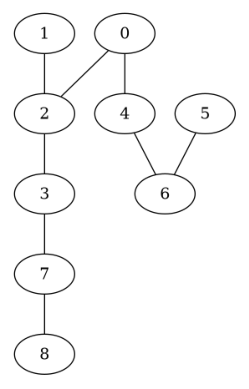

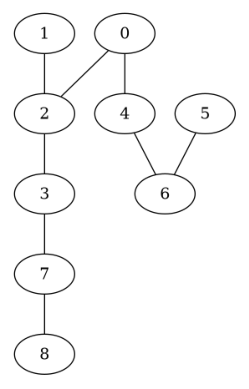

In [125]:
skeletonCPC = learnerCPC.learnSkeleton()
skeletonCPC2 = learnerCPC2.learnSkeleton()
showDot(skeletonCPC.toDot())
showDot(skeletonCPC2.toDot())

Then we look for the v-structures, leading to a Partially Directed Acyclic Graph (PDAG)



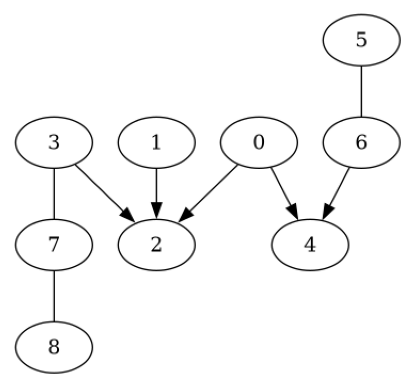

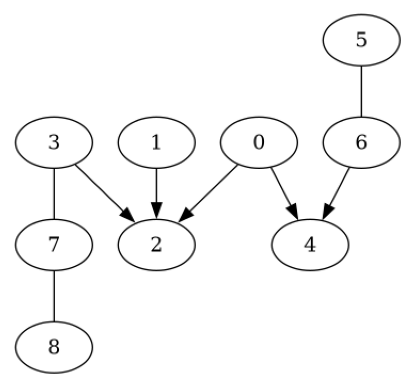

In [126]:
pdagCPC = learnerCPC.learnPDAG()
pdagCPC2 = learnerCPC2.learnPDAG()
showDot(pdagCPC.toDot())
showDot(pdagCPC2.toDot())

Finally, the remaining edges are oriented by propagating constraints



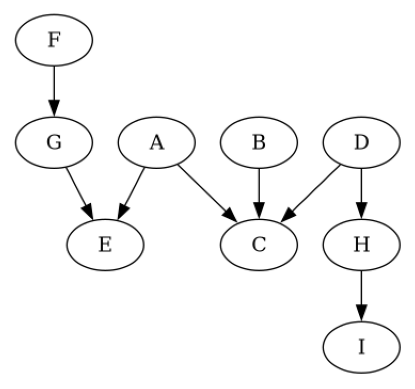

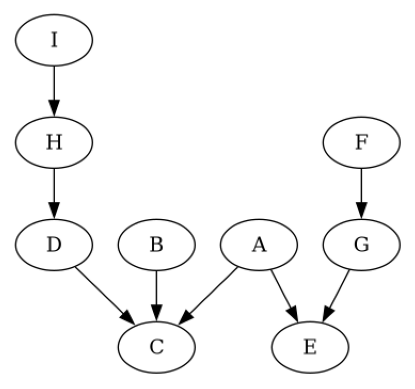

In [127]:
ndagCPC = learnerCPC.learnDAG()
ndagCPC2 = learnerCPC2.learnDAG()
showDot(ndagCPC.toDot())
showDot(ndagCPC2.toDot())

Learning with CMIIC and CMIIC2

Otagrum provides another learning algorithm to learn the structure: the CMIIC and CMIIC2 algorithm.

In [128]:
learnerCMIIC = otagrum.ContinuousMIIC(sample)
learnerCMIIC2 = otagrum.ContinuousMIIC2(sample)

This algorithm relies on the computing of mutual information which is done
through the copula function. Hence, a copula model for the data is needed.
The continuous MIIC algorithm can make use of Gaussian copulas (parametric)
or Bernstein copulas (non-parametric) to compute mutual information.
Moreover, due to finite sampling size, the mutual information estimators
need to be corrected.
Two kind of correction are provided: NoCorr (no correction) or Naive
(a fixed correction is subtracted from the raw mutual information
estimators). Those behaviours can be changed as follows:



learner.setCMode(otagrum.CorrectedMutualInformation.CModeTypes_Bernstein) # By default



In [129]:
learnerCMIIC.setCMode(
    otagrum.CorrectedMutualInformation.CModeTypes_Gaussian
)  # To use Gaussian copulas
learnerCMIIC.setKMode(otagrum.CorrectedMutualInformation.KModeTypes_Naive)  # By default
# learner.setKMode(otagrum.CorrectedMutualInformation.KModeTypes_NoCorr) # To use the raw estimators
learnerCMIIC.setAlpha(
    0.01
)  # Set the correction value for the Naive behaviour, it is set to 0.01 by default

learnerCMIIC2.setCMode(
    otagrum.CorrectedMutualInformation.CModeTypes_Gaussian
)  # To use Gaussian copulas
learnerCMIIC2.setKMode(otagrum.CorrectedMutualInformation.KModeTypes_Naive)  # By default
# learner.setKMode(otagrum.CorrectedMutualInformation.KModeTypes_NoCorr) # To use the raw estimators
learnerCMIIC2.setAlpha(
    0.01
)  # Set the correction value for the Naive behaviour, it is set to 0.01 by default

As with CPC algorithm we can learn the skeleton, PDAG and DAG using



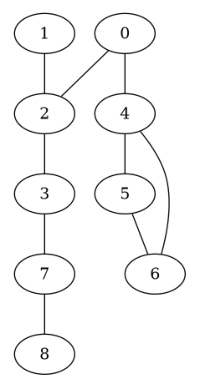

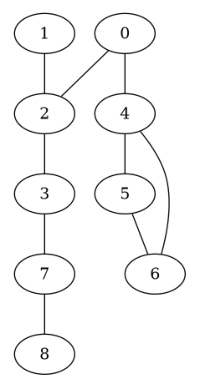

In [130]:
skeletonCMIIC = learnerCMIIC.learnSkeleton()
skeletonCMIIC2 = learnerCMIIC2.learnSkeleton()
showDot(skeletonCMIIC.toDot())
showDot(skeletonCMIIC2.toDot())

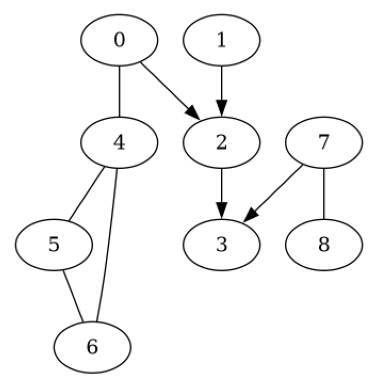

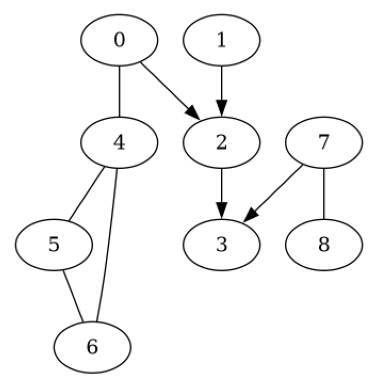

In [131]:
pdagCMIIC = learnerCMIIC.learnPDAG()
pdagCMIIC2 = learnerCMIIC2.learnPDAG()
showDot(pdagCMIIC.toDot())
showDot(pdagCMIIC2.toDot())

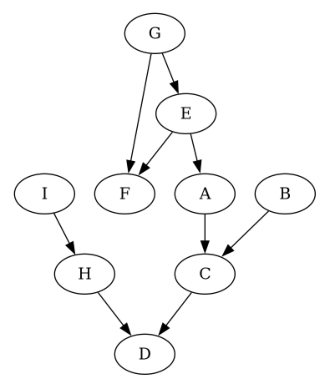

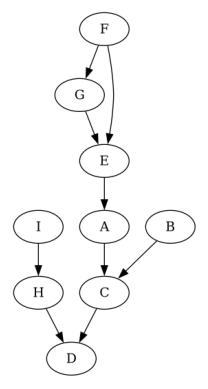

In [132]:
dagCMIIC = learnerCMIIC.learnDAG()
dagCMIIC2 = learnerCMIIC2.learnDAG()
showDot(dagCMIIC.toDot())
showDot(dagCMIIC2.toDot())

# Parameters learning

Bernstein copulas are used to learn the local conditional copulas associated to each node

In [133]:
ndag = ndagCPC # and try with ndagCPC2, ndagCMIIC and ndagCMIIC2

In [134]:
m_list = []
lcc_list = []
for i in range(train.getDimension()):
    m_list.append(ot.UniformFactory().build(train.getMarginal(i)))
    indices = [i] + [int(n) for n in ndag.getParents(i)]
    dim_lcc = len(indices)
    if dim_lcc == 1:
        bernsteinCopula = ot.IndependentCopula(1)
    elif dim_lcc > 1:
        K = otagrum.ContinuousTTest.GetK(len(train), dim_lcc)
        bernsteinCopula = ot.EmpiricalBernsteinCopula(
            train.getMarginal(indices), K, False
        )
    lcc_list.append(bernsteinCopula)

We can now create the learned CBN



In [135]:
lcbn = otagrum.ContinuousBayesianNetwork(ndag, m_list, lcc_list)  # Learned CBN

And compare the mean loglikelihood between the true and the learned models



In [136]:
def compute_mean_LL(cbn, test):
    ll = 0
    for t in test:
        ll += cbn.computeLogPDF(t)
    ll /= len(test)
    return ll

In [137]:
true_LL = compute_mean_LL(cbn, test)
print(true_LL)

0.9982980471557151


In [138]:
exp_LL = compute_mean_LL(lcbn, test)
print(exp_LL)

-1.7976931348623156e+306
